# DA_Legal Starter Pandas Notebook

This notebook provides a first-look workflow for DA legal-area data loaded from the WDFW ArcGIS API using pandas.

In [17]:
import pandas as pd

print("pandas version:", pd.__version__)

pandas version: 2.3.3


## Load Data

In [3]:
import json
from urllib.request import urlopen

api_url = "https://geodataservices.wdfw.wa.gov/arcgis/rest/services/MapServices/SharedReferenceLayers/MapServer/8/query?outFields=*&where=1%3D1&f=pjson"

with urlopen(api_url) as response:
    payload = json.load(response)

# ArcGIS query response stores each row under features -> attributes
df = pd.DataFrame([feature.get("attributes", {}) for feature in payload.get("features", [])])

print("Rows loaded from API:", len(df))
df.head()

Loading: /Users/ashleshahadkar/Documents/HCDE 530 Repository/Week 5/DA_Legal.csv


,OBJECTID,DA_Id,DA_Name,In_Effect_Desc,ShapeSTArea,ShapeSTLength
0,1,3071,Whitcomb,April 1 2026 to March 31 2027,1.280478e+08,122751.929967
1,2,3682,Ahtanum,April 1 2026 to March 31 2027,6.256904e+09,544388.268540
2,3,2010,Benge,April 1 2026 to March 31 2027,1.094324e+10,515244.178784
3,4,2011,Lakeview,April 1 2026 to March 31 2027,9.434568e+08,125604.163665
4,5,6020,Dungeness-Miller Peninsula,April 1 2026 to March 31 2027,2.145939e+09,699409.087538


## First Look

In [ ]:
df.head(100)

,OBJECTID,DA_Id,DA_Name,In_Effect_Desc,ShapeSTArea,ShapeSTLength
0,1,3071,Whitcomb,April 1 2026 to March 31 2027,1.280478e+08,1.227519e+05
1,2,3682,Ahtanum,April 1 2026 to March 31 2027,6.256904e+09,5.443883e+05
2,3,2010,Benge,April 1 2026 to March 31 2027,1.094324e+10,5.152442e+05
3,4,2011,Lakeview,April 1 2026 to March 31 2027,9.434568e+08,1.256042e+05
4,5,6020,Dungeness-Miller Peninsula,April 1 2026 to March 31 2027,2.145939e+09,6.994091e+05
5,6,2012,Methow Valley,April 1 2026 to March 31 2027,2.779350e+09,1.342952e+06
6,7,2015,Omak,April 1 2026 to March 31 2027,1.269157e+09,2.678696e+05
7,8,2016,Conconully,April 1 2026 to March 31 2027,6.530337e+08,1.528146e+05
8,9,2013,North Okanogan,April 1 2026 to March 31 2027,4.042936e+09,3.527665e+05
9,10,2014,Central Okanogan,April 1 2026 to March 31 2027,2.730659e+09,2.751975e+05


In [ ]:
df.tail()

## Structure Check

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OBJECTID        19 non-null     int64  
 1   DA_Id           19 non-null     int64  
 2   DA_Name         18 non-null     object 
 3   In_Effect_Desc  19 non-null     object 
 4   ShapeSTArea     19 non-null     float64
 5   ShapeSTLength   19 non-null     float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.0+ KB


## Summary Statistics

In [9]:
df.describe(include="all")

,OBJECTID,DA_Id,DA_Name,In_Effect_Desc,ShapeSTArea,ShapeSTLength
count,19.000000,19.000000,18,19,1.900000e+01,1.900000e+01
unique,NaN,NaN,18,1,NaN,NaN
top,NaN,NaN,Whitcomb,April 1 2026 to March 31 2027,NaN,NaN
freq,NaN,NaN,1,19,NaN,NaN
mean,10.000000,2487.263158,NaN,NaN,3.774229e+09,4.199581e+05
std,5.627314,1307.669549,NaN,NaN,5.956802e+09,3.331771e+05
min,1.000000,1008.000000,NaN,NaN,1.280478e+08,1.227519e+05
25%,5.500000,2010.500000,NaN,NaN,9.272981e+08,1.918257e+05
50%,10.000000,2015.000000,NaN,NaN,2.057166e+09,2.751975e+05
75%,14.500000,3203.000000,NaN,NaN,3.406714e+09,5.505509e+05


Matplotlib is building the font cache; this may take a moment.


Rows loaded: 354
Columns: ['OBJECTID', 'Leg_Name', 'LegB_Name', 'Active_ind', 'In_Effect_Desc', 'Shape.STLength()']

=== HEAD ===


,OBJECTID,Leg_Name,LegB_Name,Active_ind,In_Effect_Desc,Shape.STLength()
0,1,Yakima River (North Shore),None,None,April 1 2026 to March 31 2027,361476.838348
1,2,Yakima River (North Shore),None,None,April 1 2026 to March 31 2027,9614.588719
2,3,Interstate 82,None,None,April 1 2026 to March 31 2027,228390.127861
3,4,South Branch Extention Canal,None,None,April 1 2026 to March 31 2027,32821.370296
4,5,West Side canal,None,None,April 1 2026 to March 31 2027,1547.009164



=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OBJECTID          354 non-null    int64  
 1   Leg_Name          353 non-null    object 
 2   LegB_Name         38 non-null     object 
 3   Active_ind        0 non-null      object 
 4   In_Effect_Desc    354 non-null    object 
 5   Shape.STLength()  354 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 16.7+ KB

Using size column: Shape.STLength()

=== SIZE SUMMARY ===


count       354.000000
mean      22478.422328
std       44424.700693
min           2.186354
10%         882.564297
25%        2587.265028
50%        6416.211254
75%       23852.421638
90%       56295.628743
95%       83132.365071
99%      224385.539324
max      437523.026650
Name: Shape.STLength(), dtype: float64

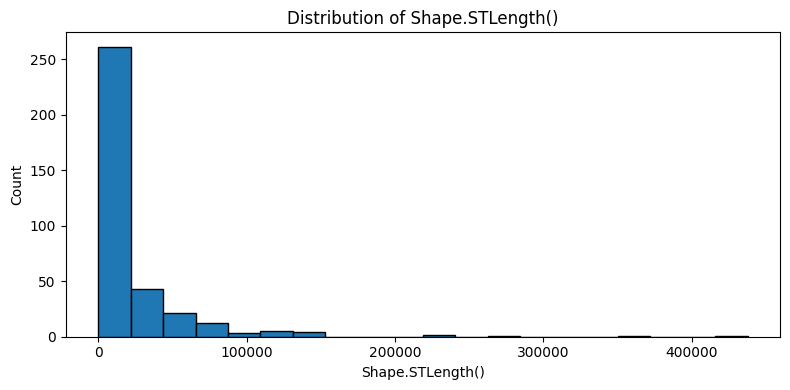


Active subset using 'Active_ind': 0 rows
Rows above 75th percentile of Shape.STLength() (nan): 0


,OBJECTID,Leg_Name,LegB_Name,Active_ind,In_Effect_Desc,Shape.STLength()



=== AVG Shape.STLength() BY In_Effect_Desc ===


,In_Effect_Desc,avg_Shape.STLength()
0,April 1 2026 to March 31 2027,22478.422328



=== MISSING VALUES ===


Active_ind    354
LegB_Name     316
Leg_Name        1
dtype: int64

In [2]:
# Full analysis block (API load + head/info + distribution + filter + groupby + missing values)
import json
from urllib.request import urlopen
import pandas as pd
from IPython.display import display

# Optional plotting support (won't crash if matplotlib is missing)
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    HAS_MATPLOTLIB = False
    print("matplotlib not installed: skipping histogram plot")

# --- 1) Load data from API into pandas ---
api_url = (
    "https://geodataservices.wdfw.wa.gov/arcgis/rest/services/MapServices/"
    "SharedReferenceLayers/MapServer/8/query?outFields=*&where=1%3D1&f=pjson"
)

with urlopen(api_url) as response:
    payload = json.load(response)

df = pd.DataFrame([f.get("attributes", {}) for f in payload.get("features", [])])

print("Rows loaded:", len(df))
print("Columns:", df.columns.tolist())

# --- 2) head() + info() ---
print("\n=== HEAD ===")
display(df.head())

print("\n=== INFO ===")
df.info()

# --- 3) Distribution of important numeric column ---
size_candidates = ["Shape.STArea()", "ShapeSTArea", "Shape.STLength()", "ShapeSTLength"]
size_col = next((c for c in size_candidates if c in df.columns), None)

if size_col is None:
    raise ValueError("No size column found (Shape.STArea()/Shape.STLength() variants).")

print(f"\nUsing size column: {size_col}")
print("\n=== SIZE SUMMARY ===")
display(df[size_col].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

if HAS_MATPLOTLIB:
    plt.figure(figsize=(8, 4))
    df[size_col].dropna().plot(kind="hist", bins=20, edgecolor="black")
    plt.title(f"Distribution of {size_col}")
    plt.xlabel(size_col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# --- 4) Filter to meaningful subset ---
# A) Active rows if active flag exists
active_candidates = ["IsActive", "Active_ind", "Active", "is_active"]
active_col = next((c for c in active_candidates if c in df.columns), None)

if active_col:
    active_true_values = {"true", "t", "yes", "y", "1", "active"}
    active_df = df[df[active_col].astype(str).str.strip().str.lower().isin(active_true_values)].copy()
    print(f"\nActive subset using '{active_col}': {len(active_df)} rows")
else:
    active_df = df.copy()
    print("\nNo active flag column found; using full dataset.")

# B) Above 75th percentile by size
threshold = active_df[size_col].quantile(0.75)
large_df = active_df[active_df[size_col] > threshold].copy()
print(f"Rows above 75th percentile of {size_col} ({threshold:.2f}): {len(large_df)}")
display(large_df.head())

# --- 5) Group by category and average size ---
group_candidates = ["In_Effect_Desc", "LegB_Name", "Leg_Name"]
group_col = next((c for c in group_candidates if c in df.columns), None)

if group_col:
    avg_by_group = (
        df.groupby(group_col, dropna=False)[size_col]
          .mean()
          .sort_values(ascending=False)
          .reset_index(name=f"avg_{size_col}")
    )
    print(f"\n=== AVG {size_col} BY {group_col} ===")
    display(avg_by_group)
else:
    print("\nNo grouping column found from:", group_candidates)

# --- 6) Missing values ---
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0] if (missing > 0).any() else missing)

## Missing Values

In [ ]:
df.isnull().sum()

OBJECTID          0
DA_Id             0
DA_Name           1
In_Effect_Desc    0
ShapeSTArea       0
ShapeSTLength     0
dtype: int64